# Linear Regression
Linear regression is a supervised machine learning algorithm used to model the relationship between a dependent variable and one or more independent variables.

It assumes a linear relationship between the input features and the target variable.

## Import Libraries
The following libraries are used for data manipulation, visualization, and model training.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset
The dataset contains information about housing area and corresponding prices.

In [38]:
df = pd.read_csv("canada_per_capita_income.csv")
df.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


## Data Visualization
We visualize the relationship between area and price to see if a linear trend exists.

Text(0, 0.5, 'Per capita income (US$)')

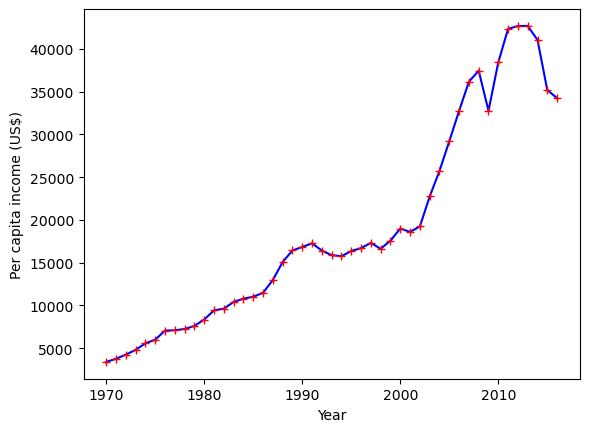

In [41]:
plt.plot(df.year,df['per capita income (US$)'], color='blue', marker='+', markeredgecolor='red')
plt.xlabel('Year')
plt.ylabel('Per capita income (US$)')

## Model Training
We train a Linear Regression model using the year as the independent variable and income as the target variable.

In [32]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [33]:
reg.fit(df[['year']], df['per capita income (US$)'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Text(0, 0.5, 'Per capita income (US$)')

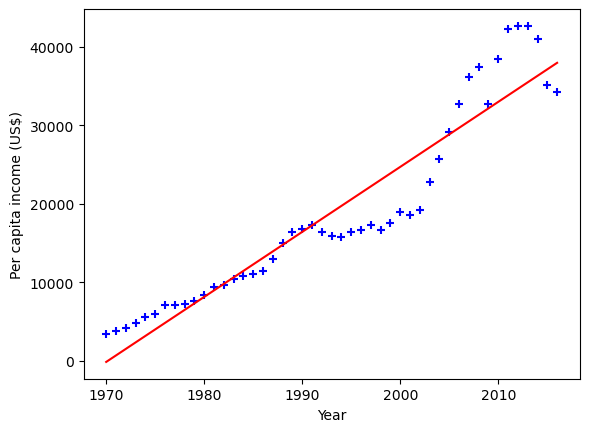

In [46]:
plt.scatter(x=df['year'],y=df['per capita income (US$)'], color='blue', marker='+')
plt.plot(df.year,reg.predict(df[['year']]),color='red')
plt.xlabel('Year')
plt.ylabel('Per capita income (US$)')

## Prediction
We can use the trained model to predict income for years 2017-2025.

In [35]:
future_years = pd.DataFrame({'year': range(2017, 2026)})

In [36]:
reg.predict(future_years)

array([38803.29886875, 39631.76394397, 40460.22901919, 41288.69409442,
       42117.15916964, 42945.62424486, 43774.08932009, 44602.55439531,
       45431.01947053])

In [42]:
future_years = pd.DataFrame({'year': list(range(2017, 2026))})


future_years['per capita income (US$)'] = reg.predict(future_years[['year']])
future_years['type'] = 'predicted'

In [43]:
hist = df[['year', 'per capita income (US$)']].copy()
hist['type'] = 'actual'

df_1970_2025 = pd.concat([hist, future_years], ignore_index=True).sort_values('year')
df_1970_2025.reset_index(drop=True, inplace=True)

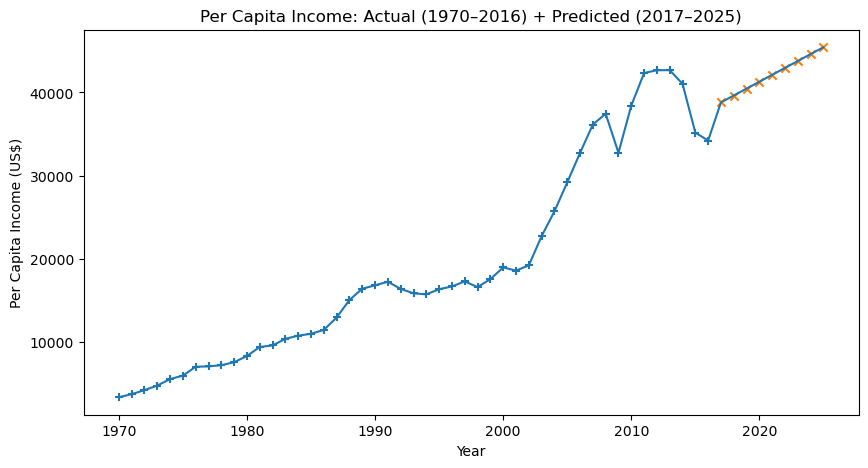

In [44]:
plt.figure(figsize=(10,5))


actual = df_1970_2025[df_1970_2025['type'] == 'actual']
plt.scatter(actual['year'], actual['per capita income (US$)'], marker='+')


pred = df_1970_2025[df_1970_2025['type'] == 'predicted']
plt.scatter(pred['year'], pred['per capita income (US$)'], marker='x')


plt.plot(df_1970_2025['year'], df_1970_2025['per capita income (US$)'])

plt.xlabel('Year')
plt.ylabel('Per Capita Income (US$)')
plt.title('Per Capita Income: Actual (1970–2016) + Predicted (2017–2025)')
plt.show()